[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laverde97/phd-data-science-ai/blob/main/semesters/semester-01/machine-learning/workshops/workshop-06-random-forest-vs-arbol-decision-regresion.ipynb)

# Random Forest vs. Árbol de Decisión para Regresión

**Machine Learning · Semestre 1**

**Autor:** Juan Sebastian Laverde Chunza

Comparación de modelos de Árbol de Decisión y Random Forest para problemas de regresión.

Este notebook realiza un **análisis exploratorio de datos completo, explicado paso a paso**, usando el conjunto de datos **Auto MPG** del **UCI Machine Learning Repository** [Auto MPG](https://towardsdatascience.com/random-forest-regression-5f605132d19d/).

### Objetivo general

Queremos entender qué características de un automóvil están relacionadas con su **eficiencia de combustible**, medida mediante `mpg` (*miles per gallon*), antes de construir un modelo de **Random Forest para regresión**.

El planteamiento que utilizaremos posteriormente será:

- **Variable objetivo (`Y`)**: `mpg` → numérica continua.
- **Variable categórica (`X`)**: `origin`.
- **Variables numéricas (`X`)**:
  - `displacement`
  - `horsepower`
  - `weight`
  - `acceleration`

> **Importante:** Primero entendemos los datos. Un buen modelo comienza con un buen conocimiento del conjunto de datos.



## 1. Sobre la base de datos

**Auto MPG** contiene información real de automóviles y fue recopilada para estudiar y predecir el consumo de combustible en ciclo urbano.

La versión publicada por UCI contiene **398 registros**. La variable que tradicionalmente se busca predecir es `mpg`.

Fuente oficial:

- UCI Machine Learning Repository — Auto MPG
- DOI: `10.24432/C5859H`
- Licencia: CC BY 4.0

### ¿Qué significa MPG?

`MPG` significa **Miles Per Gallon**, es decir, cuántas millas puede recorrer un automóvil utilizando un galón de combustible.

Por ejemplo:

- `15 mpg` → menor eficiencia de combustible.
- `30 mpg` → mayor eficiencia de combustible.

Por tanto:

> **Cuanto mayor sea el MPG, más eficiente es el vehículo en términos de consumo de combustible.**


In [3]:

# Instalamos únicamente la librería necesaria para descargar el dataset desde UCI.
# En Google Colab, pandas, numpy y matplotlib ya suelen estar disponibles.

!pip install ucimlrepo -q


In [4]:

# Librerías para manipulación y visualización de datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.



## 2. Carga de los datos desde UCI

Usaremos `ucimlrepo`, que permite descargar directamente conjuntos de datos del repositorio de UCI.

Esto tiene dos ventajas:

1. No necesitamos subir manualmente un archivo CSV.
2. Sabemos exactamente de qué fuente provienen los datos.


In [5]:

# Dataset Auto MPG = id 9 en UCI
auto_mpg = fetch_ucirepo(id=9)

# Variables predictoras y variable objetivo
X_original = auto_mpg.data.features.copy()
y_original = auto_mpg.data.targets.copy()

# Unimos X e Y para realizar el análisis exploratorio
df = pd.concat([X_original, y_original], axis=1)

print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
display(df.head())


Dimensiones del dataset: 398 filas × 8 columnas


,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.00,8,130.00,3504,12.00,70,1,18.00
1,350.00,8,165.00,3693,11.50,70,1,15.00
2,318.00,8,150.00,3436,11.00,70,1,18.00
3,304.00,8,150.00,3433,12.00,70,1,16.00
4,302.00,8,140.00,3449,10.50,70,1,17.00



## 3. Diccionario de variables

Antes de hacer gráficos o estadísticas, debemos saber **qué representa cada columna**.

| Variable | Tipo original | Significado | Papel posible |
|---|---|---|---|
| `mpg` | Numérica continua | Millas recorridas por galón de combustible | **Y / objetivo** |
| `cylinders` | Numérica discreta | Número de cilindros del motor | Predictor |
| `displacement` | Numérica continua | Cilindrada del motor, aproximadamente en pulgadas cúbicas | **X numérica** |
| `horsepower` | Numérica continua | Potencia del motor en caballos de fuerza | **X numérica** |
| `weight` | Numérica continua | Peso del automóvil en libras | **X numérica** |
| `acceleration` | Numérica continua | Tiempo aproximado para acelerar de 0 a 60 mph, en segundos | **X numérica** |
| `model_year` | Numérica discreta | Año/modelo codificado con dos dígitos, por ejemplo 70 ≈ 1970 | Predictor opcional |
| `origin` | Categórica codificada | Procedencia del vehículo: 1=USA, 2=Europa, 3=Japón | **X categórica** |

### ¿Por qué `origin` debe considerarse categórica?

Aunque UCI la almacena mediante números `1`, `2` y `3`, esos números **no representan cantidades**.

No tendría sentido afirmar que:

\[
Japón = 3 > Europa = 2 > USA = 1
\]

en términos matemáticos.

Los números solo son **códigos de categorías**. Por eso vamos a transformarlos en etiquetas comprensibles.


In [6]:

# Revisamos la información oficial de variables que devuelve UCI
display(auto_mpg.variables)


,name,role,type,demographic,description,units,missing_values
0,displacement,Feature,Continuous,None,None,None,no
1,mpg,Target,Continuous,None,None,None,no
2,cylinders,Feature,Integer,None,None,None,no
3,horsepower,Feature,Continuous,None,None,None,yes
4,weight,Feature,Continuous,None,None,None,no
5,acceleration,Feature,Continuous,None,None,None,no
6,model_year,Feature,Integer,None,None,None,no
7,origin,Feature,Integer,None,None,None,no
8,car_name,ID,Categorical,None,None,None,no



## 4. Primera inspección del dataset

En esta etapa respondemos preguntas básicas:

- ¿Cuántas filas y columnas existen?
- ¿Qué tipos de datos reconoce Python?
- ¿Hay valores faltantes?
- ¿Las variables que deberían ser numéricas realmente lo son?

Esta inspección evita errores posteriores.


In [7]:

print("Forma del dataset:", df.shape)
print("\nNombres de columnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
display(df.dtypes.to_frame("tipo_dato"))

print("\nPrimeras 10 observaciones:")
display(df.head(10))


Forma del dataset: (398, 8)

Nombres de columnas:
['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'mpg']

Tipos de datos:


,tipo_dato
displacement,float64
cylinders,int64
horsepower,float64
weight,int64
acceleration,float64
model_year,int64
origin,int64
mpg,float64



Primeras 10 observaciones:


,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.00,8,130.00,3504,12.00,70,1,18.00
1,350.00,8,165.00,3693,11.50,70,1,15.00
2,318.00,8,150.00,3436,11.00,70,1,18.00
3,304.00,8,150.00,3433,12.00,70,1,16.00
4,302.00,8,140.00,3449,10.50,70,1,17.00
5,429.00,8,198.00,4341,10.00,70,1,15.00
6,454.00,8,220.00,4354,9.00,70,1,14.00
7,440.00,8,215.00,4312,8.50,70,1,14.00
8,455.00,8,225.00,4425,10.00,70,1,14.00
9,390.00,8,190.00,3850,8.50,70,1,15.00



### Interpretación

Cada fila representa un automóvil.

Cada columna representa una característica del automóvil o la variable que queremos explicar.

En un problema supervisado de regresión podemos pensar en:

$$
Y = f(X_1, X_2, \ldots, X_p) + \varepsilon
$$

En nuestro caso, más adelante queremos aproximar:

$$
MPG = f(Origen, Cilindrada, Potencia, Peso, Aceleración)
$$

mediante un **Random Forest Regressor**.



## 5. Limpieza mínima para el EDA

La variable `horsepower` contiene algunos valores faltantes en la versión de UCI.

Antes de calcular estadísticas, nos aseguramos de que las variables cuantitativas tengan tipo numérico.


In [8]:

# Columnas que deberían ser numéricas
numeric_candidates = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "mpg"
]

for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Conversión a formato numérico completada.")
display(df.dtypes.to_frame("tipo_dato"))


Conversión a formato numérico completada.


,tipo_dato
displacement,float64
cylinders,int64
horsepower,float64
weight,int64
acceleration,float64
model_year,int64
origin,int64
mpg,float64



## 6. Valores faltantes

Los valores faltantes son observaciones para las cuales no conocemos el dato de una variable.

Por ejemplo, si un automóvil no tiene reportado su `horsepower`, esa celda aparecerá como `NaN`.

### ¿Por qué importa?

Muchos algoritmos no pueden trabajar directamente con valores faltantes. Más adelante tendremos que decidir si:

- eliminamos esas filas,
- imputamos la mediana,
- imputamos la media,
- o usamos otra estrategia.

Para este EDA **no vamos a ocultar el problema**: primero lo cuantificamos.


,faltantes,porcentaje
horsepower,6,1.51
displacement,0,0.00
cylinders,0,0.00
weight,0,0.00
acceleration,0,0.00
model_year,0,0.00
origin,0,0.00
mpg,0,0.00


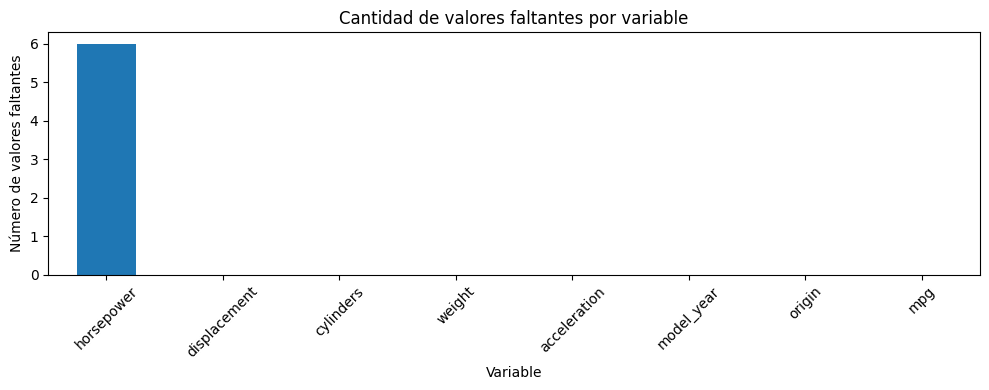

In [9]:

missing = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "porcentaje": df.isna().mean() * 100
}).sort_values("faltantes", ascending=False)

display(missing)

ax = missing["faltantes"].plot(kind="bar", figsize=(10, 4))
ax.set_title("Cantidad de valores faltantes por variable")
ax.set_xlabel("Variable")
ax.set_ylabel("Número de valores faltantes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### ¿Qué esperamos encontrar?

La documentación de UCI señala que `horsepower` presenta valores faltantes.

Si aparecen pocos casos, eso no significa que debamos eliminarlos automáticamente. La estrategia correcta se decidirá antes del modelado para evitar pérdida innecesaria de información.



## 7. Estadística descriptiva

Ahora calculamos medidas como:

- **media**: valor promedio.
- **desviación estándar**: dispersión alrededor de la media.
- **mínimo y máximo**: extremos observados.
- **25%, 50%, 75%**: cuartiles.
- **50%** corresponde a la **mediana**.

Estas medidas nos ayudan a entender la escala de cada variable.


In [10]:

display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
displacement,398.00,193.43,104.27,68.00,104.25,148.50,262.00,455.00
cylinders,398.00,5.45,1.70,3.00,4.00,4.00,8.00,8.00
horsepower,392.00,104.47,38.49,46.00,75.00,93.50,126.00,230.00
weight,398.00,"2,970.42",846.84,"1,613.00","2,223.75","2,803.50","3,608.00","5,140.00"
acceleration,398.00,15.57,2.76,8.00,13.83,15.50,17.18,24.80
model_year,398.00,76.01,3.70,70.00,73.00,76.00,79.00,82.00
origin,398.00,1.57,0.80,1.00,1.00,1.00,2.00,3.00
mpg,398.00,23.51,7.82,9.00,17.50,23.00,29.00,46.60



## 8. Transformación de `origin` a variable categórica

Los códigos originales son:

- `1` → USA
- `2` → Europe
- `3` → Japan

Crearemos una nueva columna llamada `origin_label` para que los resultados sean mucho más fáciles de interpretar.

> Conservamos `origin` y creamos una etiqueta adicional. Así podemos comparar el código original con su significado.


In [11]:

origin_map = {
    1: "USA",
    2: "Europe",
    3: "Japan"
}

df["origin_label"] = df["origin"].map(origin_map).astype("category")

display(df[["origin", "origin_label"]].head(10))

print("\nFrecuencia por origen:")
display(df["origin_label"].value_counts(dropna=False).to_frame("cantidad"))


,origin,origin_label
0,1,USA
1,1,USA
2,1,USA
3,1,USA
4,1,USA
5,1,USA
6,1,USA
7,1,USA
8,1,USA
9,1,USA



Frecuencia por origen:


,cantidad
origin_label,
USA,249
Japan,79
Europe,70



## 9. Distribución de la variable objetivo: `mpg`

`mpg` será nuestra **Y**.

Antes de intentar predecirla debemos conocer:

- su rango,
- su valor promedio,
- su mediana,
- si está concentrada o dispersa,
- si existen valores extremos,
- y la forma general de su distribución.

Un histograma permite observar cuántos vehículos se encuentran en diferentes rangos de MPG.


Media de MPG:    23.51
Mediana de MPG:  23.00
Mínimo de MPG:   9.00
Máximo de MPG:   46.60
Desv. estándar:  7.82


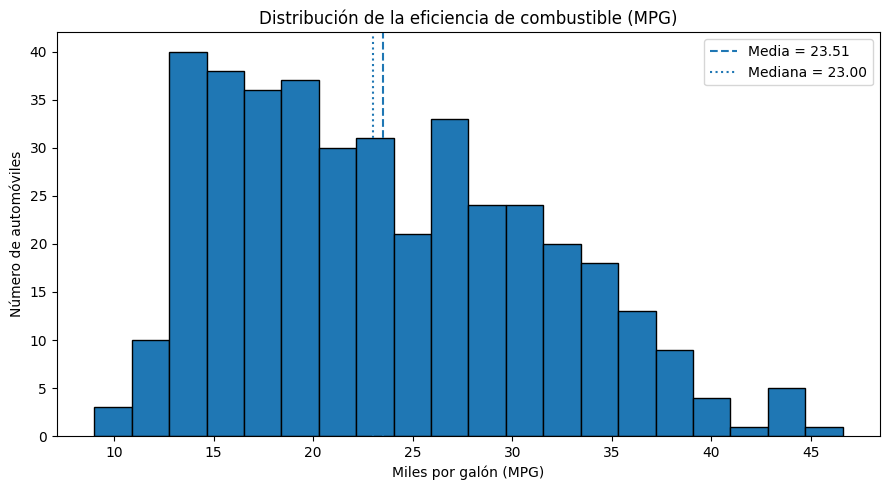

In [12]:

mpg = df["mpg"].dropna()

print(f"Media de MPG:    {mpg.mean():.2f}")
print(f"Mediana de MPG:  {mpg.median():.2f}")
print(f"Mínimo de MPG:   {mpg.min():.2f}")
print(f"Máximo de MPG:   {mpg.max():.2f}")
print(f"Desv. estándar:  {mpg.std():.2f}")

plt.figure(figsize=(9, 5))
plt.hist(mpg, bins=20, edgecolor="black")
plt.axvline(mpg.mean(), linestyle="--", label=f"Media = {mpg.mean():.2f}")
plt.axvline(mpg.median(), linestyle=":", label=f"Mediana = {mpg.median():.2f}")
plt.title("Distribución de la eficiencia de combustible (MPG)")
plt.xlabel("Miles por galón (MPG)")
plt.ylabel("Número de automóviles")
plt.legend()
plt.tight_layout()
plt.show()



### Cómo interpretar este gráfico

- Si muchos automóviles se concentran en valores bajos de MPG, predominan vehículos menos eficientes.
- Si aparecen muchos valores altos, existen más vehículos con mayor eficiencia.
- Una gran distancia entre el mínimo y el máximo indica considerable variabilidad entre automóviles.

No debemos interpretar un histograma únicamente como “bueno” o “malo”. Su función aquí es mostrarnos **cómo se distribuye la variable que el modelo deberá aprender a predecir**.



## 10. Análisis de `origin` — nuestra X categórica

Queremos responder:

1. ¿Cuántos automóviles hay de cada origen?
2. ¿El MPG presenta diferencias entre los grupos?
3. ¿Hay desbalance en el número de observaciones?

Este análisis es importante porque `origin` será la variable categórica principal del futuro modelo.


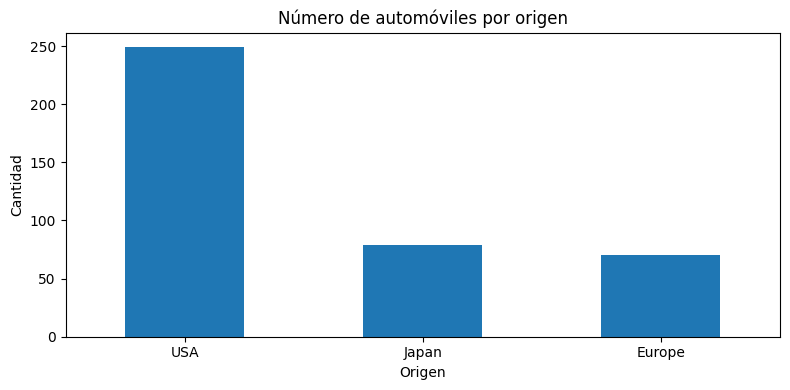

Cantidad y porcentaje:


,cantidad,porcentaje
origin_label,,
USA,249,62.56
Japan,79,19.85
Europe,70,17.59


In [13]:

origin_counts = df["origin_label"].value_counts()

ax = origin_counts.plot(kind="bar", figsize=(8, 4))
ax.set_title("Número de automóviles por origen")
ax.set_xlabel("Origen")
ax.set_ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Cantidad y porcentaje:")
origin_summary = pd.DataFrame({
    "cantidad": origin_counts,
    "porcentaje": origin_counts / len(df) * 100
})
display(origin_summary)


,count,mean,median,std,min,max
origin_label,,,,,,
Japan,79,30.45,31.60,6.09,18.00,46.60
Europe,70,27.89,26.50,6.72,16.20,44.30
USA,249,20.08,18.50,6.40,9.00,39.00


/tmp/ipykernel_2379/367618709.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


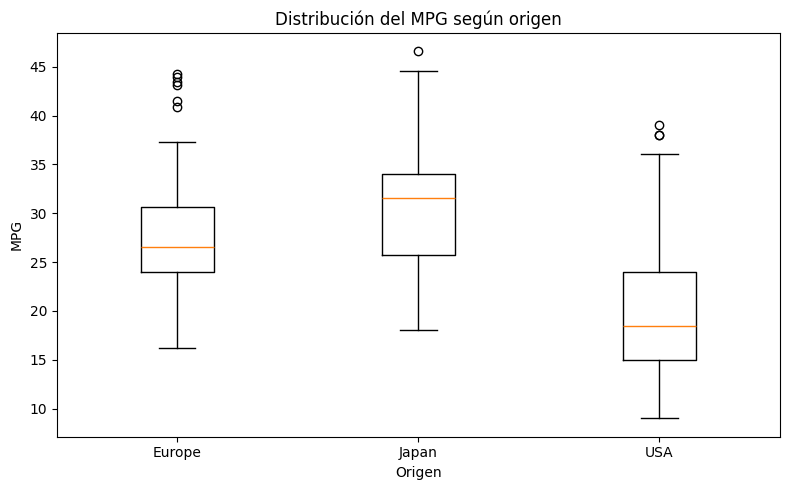

In [14]:

# Resumen de MPG según origen
mpg_by_origin = (
    df.groupby("origin_label", observed=True)["mpg"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .sort_values("mean", ascending=False)
)

display(mpg_by_origin)

# Boxplot sin seaborn
groups = []
labels = []

for category in df["origin_label"].cat.categories:
    values = df.loc[df["origin_label"] == category, "mpg"].dropna()
    groups.append(values)
    labels.append(category)

plt.figure(figsize=(8, 5))
plt.boxplot(groups, labels=labels)
plt.title("Distribución del MPG según origen")
plt.xlabel("Origen")
plt.ylabel("MPG")
plt.tight_layout()
plt.show()



### Cómo interpretar el boxplot

Un boxplot permite comparar la distribución de MPG entre categorías.

- La línea dentro de cada caja representa la **mediana**.
- La caja cubre aproximadamente el 50% central de los datos.
- Los puntos alejados pueden representar observaciones extremas.

Si las medianas de MPG cambian entre USA, Europe y Japan, existe una **asociación descriptiva** entre origen y eficiencia de combustible.

> Esto no demuestra que el origen sea la causa de la diferencia. Por ejemplo, los vehículos de distintos orígenes también pueden diferir en peso, potencia, cilindrada o año.



# 11. Análisis individual de las variables numéricas X

Trabajaremos principalmente con:

- `displacement`
- `horsepower`
- `weight`
- `acceleration`

Para cada variable estudiaremos:

1. qué significa,
2. cómo se distribuye,
3. cómo se relaciona visualmente con `mpg`.


In [15]:

def explorar_numerica(df, variable, target="mpg", bins=20):
    """Muestra resumen, histograma y dispersión frente a la variable objetivo."""

    temp = df[[variable, target]].dropna()

    print(f"VARIABLE: {variable}")
    print("-" * 60)
    print(temp[variable].describe())

    plt.figure(figsize=(8, 4))
    plt.hist(temp[variable], bins=bins, edgecolor="black")
    plt.title(f"Distribución de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.scatter(temp[variable], temp[target], alpha=0.65)
    plt.title(f"{variable} vs {target}")
    plt.xlabel(variable)
    plt.ylabel(target)
    plt.tight_layout()
    plt.show()



## 11.1 `displacement` — cilindrada del motor

La **cilindrada** representa el volumen total desplazado por los pistones del motor.

En este dataset se expresa aproximadamente en **pulgadas cúbicas**.

### Intuición

Un motor de mayor cilindrada suele ser un motor de mayor tamaño. Históricamente, en automóviles de este periodo, los motores grandes podían asociarse con:

- mayor potencia,
- vehículos más pesados,
- mayor consumo de combustible.

Por eso nos interesa comprobar visualmente si, dentro de esta muestra, los valores altos de `displacement` tienden a relacionarse con valores menores de `mpg`.


VARIABLE: displacement
------------------------------------------------------------
count   398.00
mean    193.43
std     104.27
min      68.00
25%     104.25
50%     148.50
75%     262.00
max     455.00
Name: displacement, dtype: float64


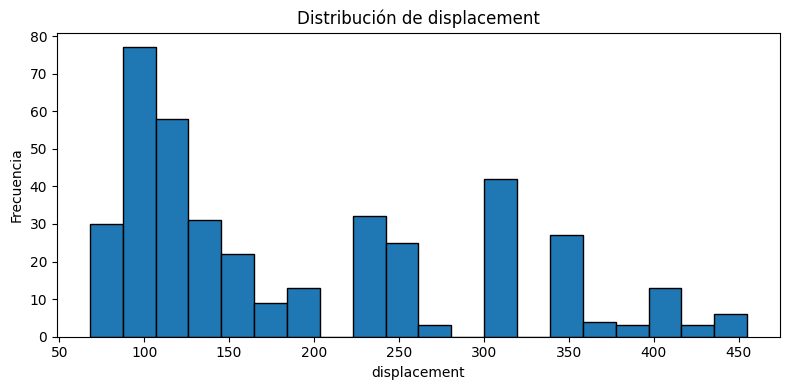

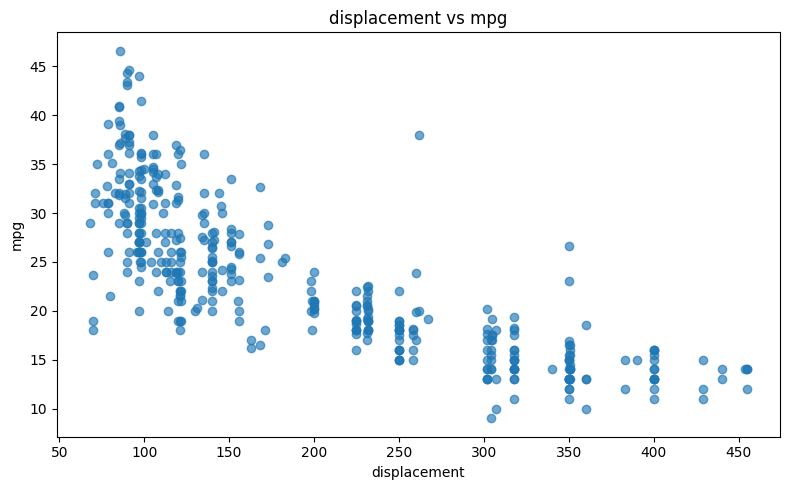

In [16]:
explorar_numerica(df, 'displacement')


## 11.2 `horsepower` — potencia del motor

`horsepower` mide la **potencia del motor** en caballos de fuerza.

### Intuición

Un valor alto indica un motor capaz de entregar más potencia.

Podría existir una relación entre mayor potencia y menor MPG en esta muestra, pero no debemos asumirla antes de mirar los datos.

Además, esta variable merece atención porque contiene algunos valores faltantes.


VARIABLE: horsepower
------------------------------------------------------------
count   392.00
mean    104.47
std      38.49
min      46.00
25%      75.00
50%      93.50
75%     126.00
max     230.00
Name: horsepower, dtype: float64


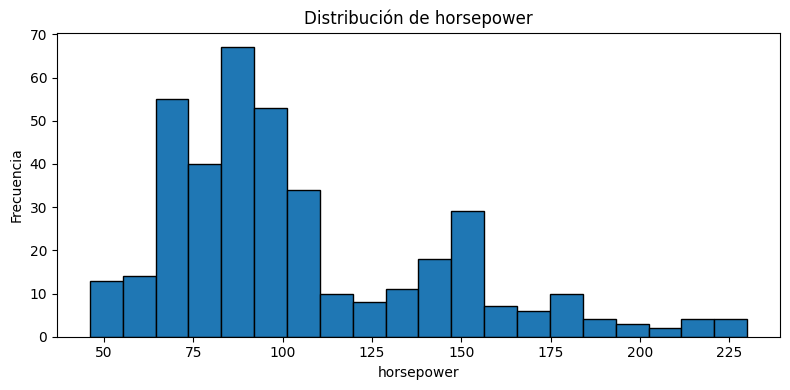

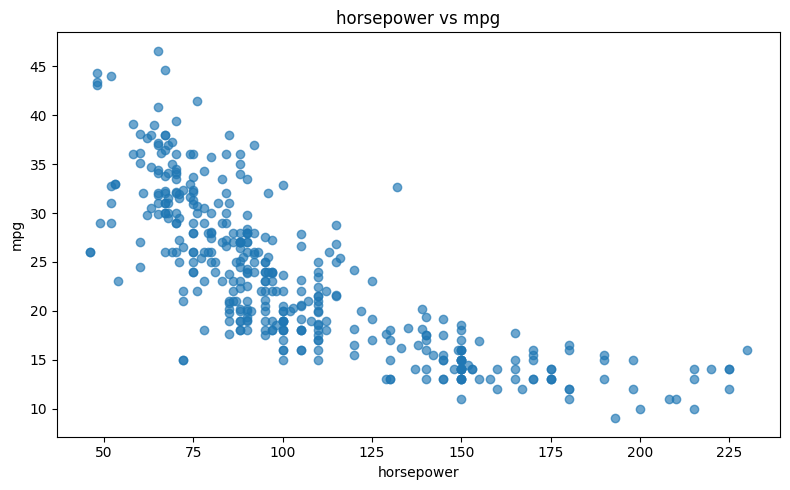

In [17]:
explorar_numerica(df, 'horsepower')


## 11.3 `weight` — peso del automóvil

`weight` representa el **peso del vehículo en libras**.

### ¿Por qué puede ser importante?

Mover un automóvil pesado requiere más energía que mover uno ligero, manteniendo otros factores constantes.

Por eso `weight` suele ser una variable muy informativa al estudiar consumo de combustible.

En el gráfico analizaremos si los vehículos más pesados presentan, dentro de esta base, una tendencia hacia valores menores de MPG.


VARIABLE: weight
------------------------------------------------------------
count     398.00
mean    2,970.42
std       846.84
min     1,613.00
25%     2,223.75
50%     2,803.50
75%     3,608.00
max     5,140.00
Name: weight, dtype: float64


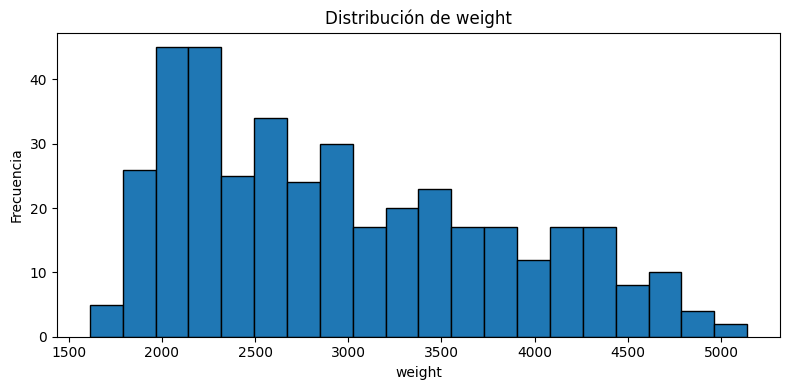

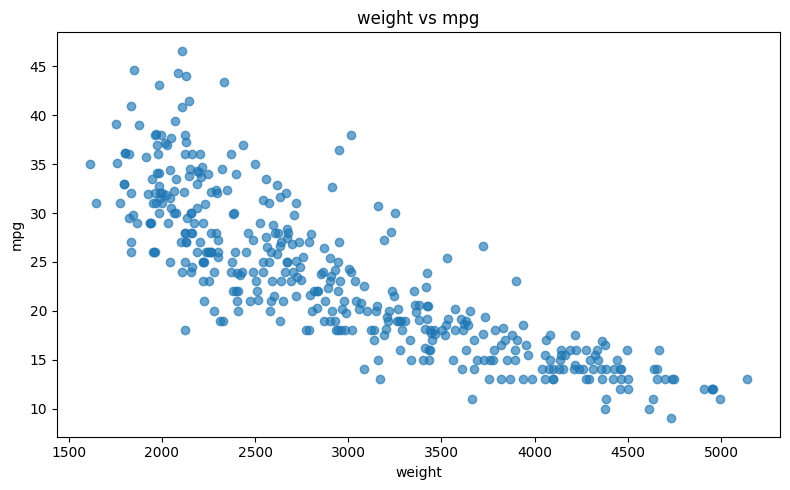

In [18]:
explorar_numerica(df, 'weight')


## 11.4 `acceleration` — tiempo de aceleración

En Auto MPG, `acceleration` representa aproximadamente el **tiempo en segundos que tarda el vehículo en acelerar de 0 a 60 mph**.

### Una interpretación importante

Aquí un número **más grande** significa que el automóvil tarda más tiempo en acelerar.

Por ejemplo:

- `10 segundos` → acelera más rápidamente.
- `18 segundos` → tarda más en alcanzar 60 mph.

Por eso no debemos confundir esta variable con “cantidad de aceleración”: se comporta como una medida de **tiempo de aceleración**.


VARIABLE: acceleration
------------------------------------------------------------
count   398.00
mean     15.57
std       2.76
min       8.00
25%      13.83
50%      15.50
75%      17.18
max      24.80
Name: acceleration, dtype: float64


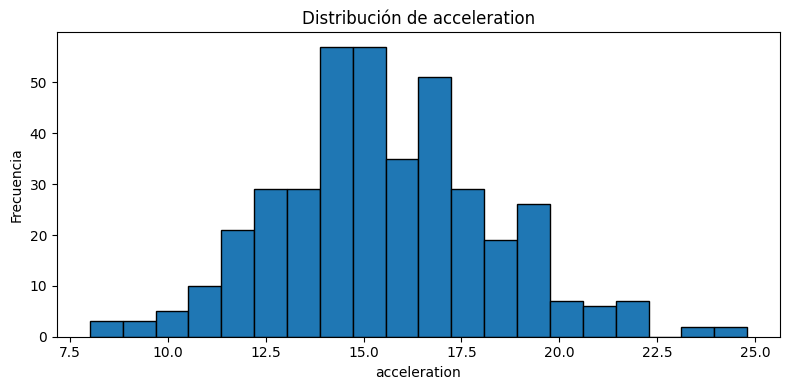

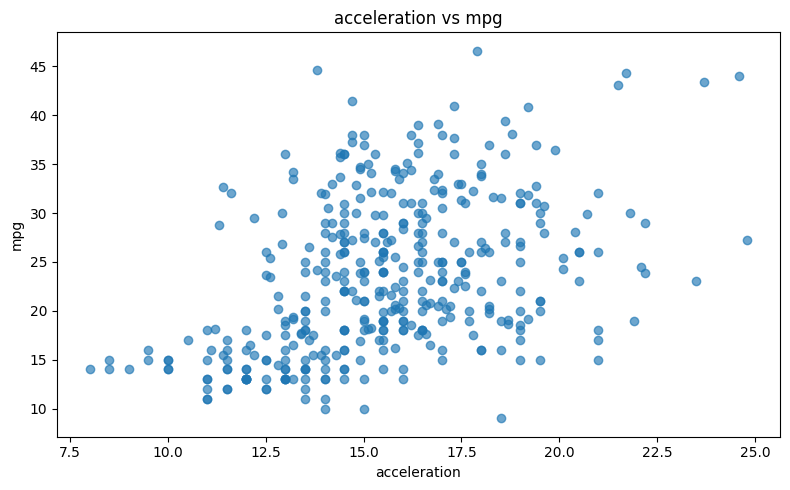

In [19]:
explorar_numerica(df, 'acceleration')


## 12. Variables adicionales disponibles

Aunque para nuestro primer Random Forest no necesariamente utilizaremos todas, es útil entenderlas.



### `cylinders` — número de cilindros

Indica cuántos cilindros posee el motor.

Aunque Python la interpreta como número, conceptualmente es una variable **discreta**.

Es común que motores con más cilindros también tengan mayor cilindrada y potencia, por lo que puede existir información redundante o relacionada entre estas variables.


Frecuencia del número de cilindros:


,cantidad
cylinders,
3,4
4,204
5,3
6,84
8,103


,count,mean,median
cylinders,,,
3,4,20.55,20.25
4,204,29.29,28.25
5,3,27.37,25.40
6,84,19.99,19.00
8,103,14.96,14.00


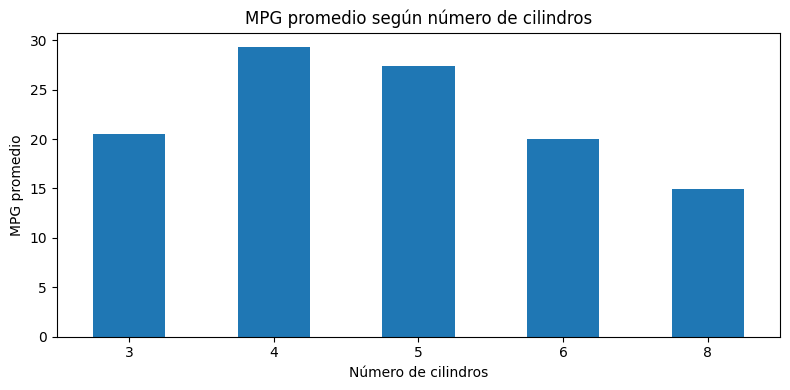

In [20]:

print("Frecuencia del número de cilindros:")
display(df["cylinders"].value_counts().sort_index().to_frame("cantidad"))

cyl_mpg = df.groupby("cylinders")["mpg"].agg(["count", "mean", "median"])
display(cyl_mpg)

ax = cyl_mpg["mean"].plot(kind="bar", figsize=(8, 4))
ax.set_title("MPG promedio según número de cilindros")
ax.set_xlabel("Número de cilindros")
ax.set_ylabel("MPG promedio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



### `model_year` — año del modelo

Representa el año del vehículo mediante los últimos dos dígitos.

Ejemplos:

- `70` → aproximadamente 1970
- `75` → aproximadamente 1975
- `82` → aproximadamente 1982

Esta variable puede ser importante porque la tecnología automotriz y las características de los vehículos cambiaron durante el periodo observado.


,count,mean,median
model_year,,,
70,29,17.69,16.00
71,28,21.25,19.00
72,28,18.71,18.50
73,40,17.10,16.00
74,27,22.70,24.00
75,30,20.27,19.50
76,34,21.57,21.00
77,28,23.38,21.75
78,36,24.06,20.70


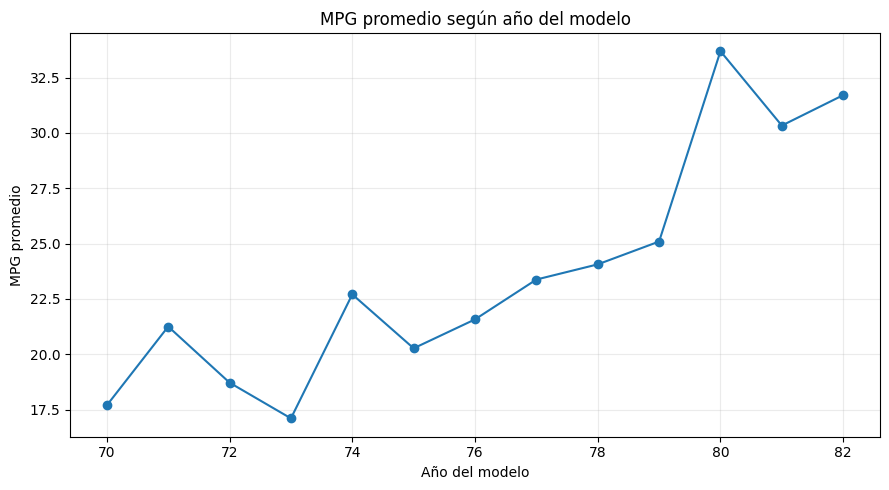

In [21]:

year_summary = df.groupby("model_year")["mpg"].agg(["count", "mean", "median"])
display(year_summary)

plt.figure(figsize=(9, 5))
plt.plot(year_summary.index, year_summary["mean"], marker="o")
plt.title("MPG promedio según año del modelo")
plt.xlabel("Año del modelo")
plt.ylabel("MPG promedio")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()



# 13. Correlaciones entre variables numéricas

La **correlación de Pearson** mide la fuerza de una relación lineal entre dos variables numéricas.

Sus valores están entre `-1` y `1`:

- cerca de `+1` → relación lineal positiva fuerte.
- cerca de `-1` → relación lineal negativa fuerte.
- cerca de `0` → poca relación lineal.

### Advertencia

Correlación **no implica causalidad**.

Además, Random Forest puede aprender relaciones no lineales, por lo que una correlación pequeña no significa automáticamente que una variable sea inútil.


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.00,-0.78,-0.80,-0.78,-0.83,0.42,0.58
cylinders,-0.78,1.00,0.95,0.84,0.90,-0.51,-0.35
displacement,-0.80,0.95,1.00,0.90,0.93,-0.54,-0.37
horsepower,-0.78,0.84,0.90,1.00,0.86,-0.69,-0.42
weight,-0.83,0.90,0.93,0.86,1.00,-0.42,-0.31
acceleration,0.42,-0.51,-0.54,-0.69,-0.42,1.00,0.29
model_year,0.58,-0.35,-0.37,-0.42,-0.31,0.29,1.00


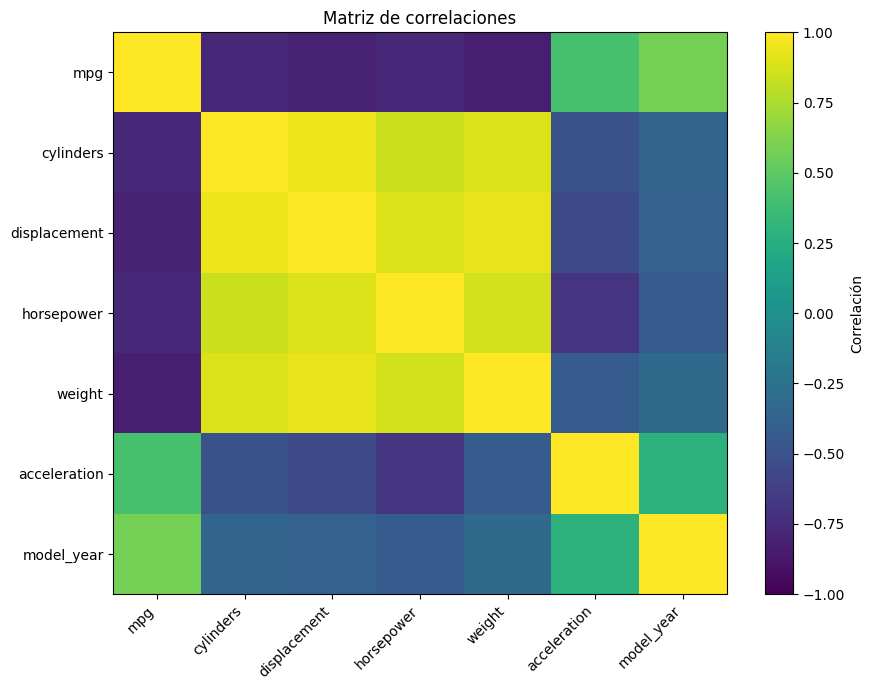

In [22]:

numeric_for_corr = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year"
]

corr = df[numeric_for_corr].corr()

display(corr.round(3))

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Matriz de correlaciones")
plt.tight_layout()
plt.show()


In [23]:

# Correlación de cada predictor numérico con MPG
corr_with_mpg = (
    corr["mpg"]
    .drop("mpg")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("correlacion_con_mpg")
)

display(corr_with_mpg)


,correlacion_con_mpg
weight,-0.83
displacement,-0.80
horsepower,-0.78
cylinders,-0.78
model_year,0.58
acceleration,0.42



### Cómo leer este resultado

La tabla anterior ordena las variables según la magnitud de su asociación lineal con `mpg`.

- Signo **positivo**: cuando la variable aumenta, MPG tiende a aumentar.
- Signo **negativo**: cuando la variable aumenta, MPG tiende a disminuir.
- Magnitud cercana a `1`: asociación lineal fuerte.
- Magnitud cercana a `0`: asociación lineal débil.

Esta es una exploración descriptiva, no una selección definitiva de variables.



# 14. Relaciones entre las variables predictoras

También debemos estudiar si las X están relacionadas entre sí.

Por ejemplo:

- `displacement` y `horsepower` pueden moverse conjuntamente.
- `weight` puede estar relacionado con cilindrada.
- `cylinders` puede guardar relación con tamaño y potencia del motor.

Random Forest suele tolerar variables correlacionadas mejor que una regresión lineal tradicional, aunque la correlación entre predictores sí puede afectar la interpretación de las importancias.


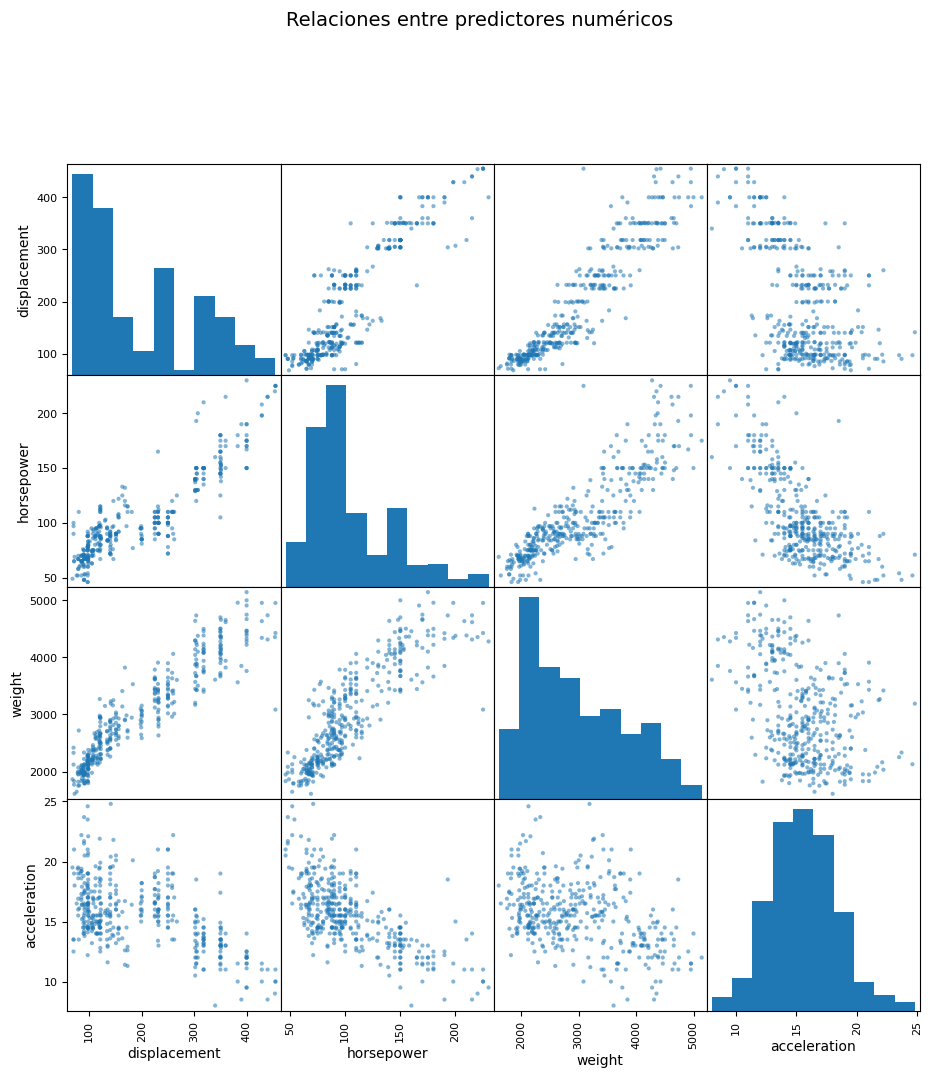

In [24]:

predictors = ["displacement", "horsepower", "weight", "acceleration"]

pd.plotting.scatter_matrix(
    df[predictors],
    figsize=(11, 11),
    diagonal="hist",
    alpha=0.55
)

plt.suptitle(
    "Relaciones entre predictores numéricos",
    y=1.02,
    fontsize=14
)
plt.show()



# 15. Detección exploratoria de posibles valores atípicos

Un **valor atípico** es una observación alejada de la mayor parte de los datos.

No debemos eliminar un dato solamente porque sea extremo. Puede representar:

- un error,
- un vehículo realmente inusual,
- o una observación perfectamente válida.

Usaremos la regla del rango intercuartílico (IQR) únicamente como herramienta de exploración.


In [25]:

variables_outliers = [
    "mpg",
    "displacement",
    "horsepower",
    "weight",
    "acceleration"
]

outlier_rows = []

for variable in variables_outliers:
    s = df[variable].dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = ((s < lower) | (s > upper)).sum()

    outlier_rows.append({
        "variable": variable,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior": lower,
        "limite_superior": upper,
        "posibles_atipicos": n_outliers
    })

outliers_summary = pd.DataFrame(outlier_rows)
display(outliers_summary)


,variable,Q1,Q3,IQR,limite_inferior,limite_superior,posibles_atipicos
0,mpg,17.50,29.00,11.50,0.25,46.25,1
1,displacement,104.25,262.00,157.75,-132.38,498.62,0
2,horsepower,75.00,126.00,51.00,-1.50,202.50,10
3,weight,"2,223.75","3,608.00","1,384.25",147.38,"5,684.38",0
4,acceleration,13.83,17.18,3.35,8.80,22.20,7


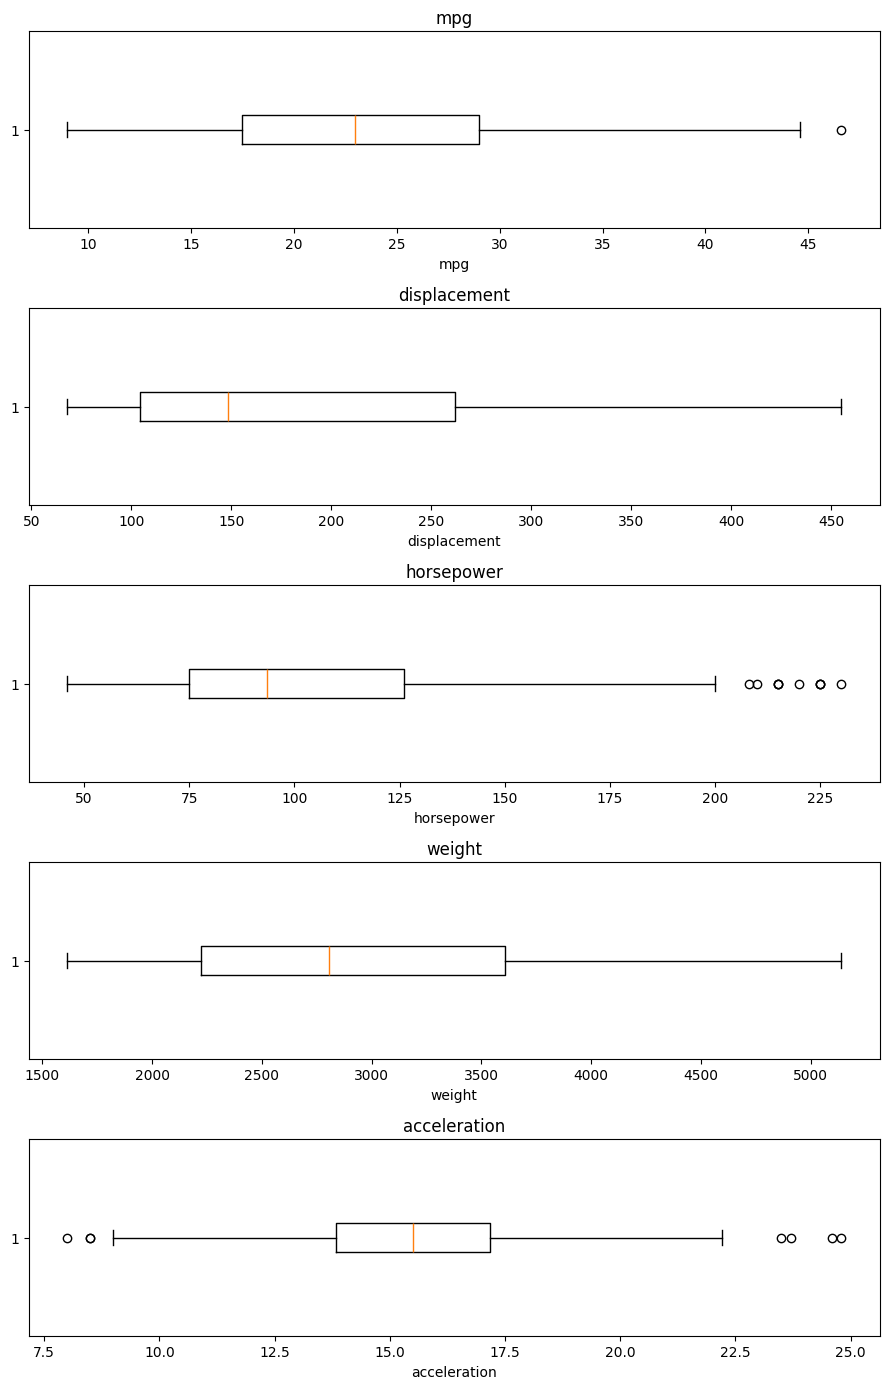

In [26]:

# Boxplots individuales para revisar visualmente valores extremos

fig, axes = plt.subplots(
    nrows=len(variables_outliers),
    ncols=1,
    figsize=(9, 14)
)

for ax, variable in zip(axes, variables_outliers):
    ax.boxplot(df[variable].dropna(), vert=False)
    ax.set_title(variable)
    ax.set_xlabel(variable)

plt.tight_layout()
plt.show()



# 16. Relación conjunta: origen, peso y MPG

Un análisis interesante consiste en combinar una variable categórica (`origin`) con una numérica (`weight`) y observar `mpg`.

Así podemos revisar si las diferencias entre regiones podrían estar relacionadas también con diferencias en el peso de los automóviles.


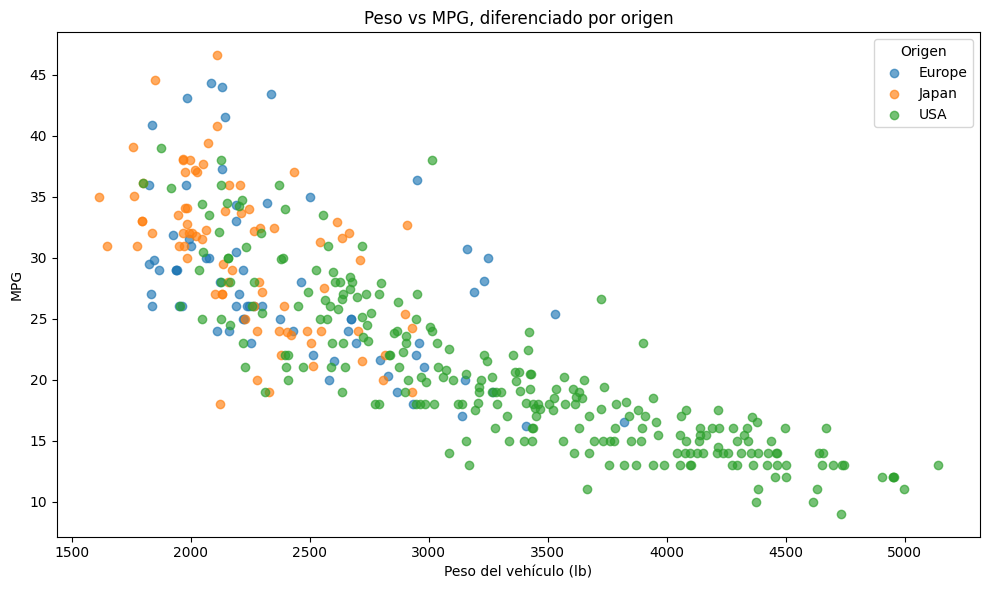

In [27]:

plt.figure(figsize=(10, 6))

for category in df["origin_label"].cat.categories:
    subset = df[df["origin_label"] == category]

    plt.scatter(
        subset["weight"],
        subset["mpg"],
        alpha=0.65,
        label=category
    )

plt.title("Peso vs MPG, diferenciado por origen")
plt.xlabel("Peso del vehículo (lb)")
plt.ylabel("MPG")
plt.legend(title="Origen")
plt.tight_layout()
plt.show()



### Qué buscamos aquí

Queremos evitar conclusiones demasiado simples.

Por ejemplo, si un origen presenta mayor MPG promedio, podría deberse en parte a que sus automóviles son más ligeros.

Esto ilustra una idea fundamental en análisis de datos:

> **Las variables no deben estudiarse únicamente de forma aislada.**



# 17. Dataset que utilizaremos para Random Forest

Ahora construiremos exactamente la estructura que queremos para el futuro modelo.

## X predictoras

### Categórica
- `origin_label`

### Numéricas
- `displacement`
- `horsepower`
- `weight`
- `acceleration`

## Y objetivo
- `mpg`

Matemáticamente:

$$
\hat{MPG}
=
f(
Origin,
Displacement,
Horsepower,
Weight,
Acceleration
)
$$

donde `f` será posteriormente aprendida por un **Random Forest Regressor**.


In [28]:

features_model = [
    "origin_label",
    "displacement",
    "horsepower",
    "weight",
    "acceleration"
]

target_model = "mpg"

df_modelo = df[features_model + [target_model]].copy()

print("Dataset preparado para la siguiente etapa:")
print(df_modelo.shape)
display(df_modelo.head(10))


Dataset preparado para la siguiente etapa:
(398, 6)


,origin_label,displacement,horsepower,weight,acceleration,mpg
0,USA,307.00,130.00,3504,12.00,18.00
1,USA,350.00,165.00,3693,11.50,15.00
2,USA,318.00,150.00,3436,11.00,18.00
3,USA,304.00,150.00,3433,12.00,16.00
4,USA,302.00,140.00,3449,10.50,17.00
5,USA,429.00,198.00,4341,10.00,15.00
6,USA,454.00,220.00,4354,9.00,14.00
7,USA,440.00,215.00,4312,8.50,14.00
8,USA,455.00,225.00,4425,10.00,14.00
9,USA,390.00,190.00,3850,8.50,15.00


In [29]:

print("Tipos de variables del dataset de modelado:")
display(df_modelo.dtypes.to_frame("tipo"))

print("\nValores faltantes:")
display(df_modelo.isna().sum().to_frame("faltantes"))


Tipos de variables del dataset de modelado:


,tipo
origin_label,category
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
mpg,float64



Valores faltantes:


,faltantes
origin_label,0
displacement,0
horsepower,6
weight,0
acceleration,0
mpg,0



# 18. Resumen automatizado del EDA

Esta celda genera algunos indicadores clave para cerrar el análisis exploratorio.


In [30]:

print("=" * 70)
print("RESUMEN DEL ANÁLISIS EXPLORATORIO")
print("=" * 70)

print(f"Observaciones totales: {len(df):,}")
print(f"Variables analizadas: {df.shape[1]}")

print("\nVariable objetivo:")
print(f"  MPG medio   : {df['mpg'].mean():.2f}")
print(f"  MPG mediano : {df['mpg'].median():.2f}")
print(f"  Rango MPG   : {df['mpg'].min():.2f} - {df['mpg'].max():.2f}")

print("\nVariable categórica:")
print(df["origin_label"].value_counts())

print("\nValores faltantes:")
print(df_modelo.isna().sum())

print("\nCorrelaciones numéricas con MPG:")
for variable in ["displacement", "horsepower", "weight", "acceleration"]:
    value = df[[variable, "mpg"]].corr().loc[variable, "mpg"]
    print(f"  {variable:15s}: {value: .3f}")

print("\nDataset final para modelado:")
print(df_modelo.shape)


RESUMEN DEL ANÁLISIS EXPLORATORIO
Observaciones totales: 398
Variables analizadas: 9

Variable objetivo:
  MPG medio   : 23.51
  MPG mediano : 23.00
  Rango MPG   : 9.00 - 46.60

Variable categórica:
origin_label
USA       249
Japan      79
Europe     70
Name: count, dtype: int64

Valores faltantes:
origin_label    0
displacement    0
horsepower      6
weight          0
acceleration    0
mpg             0
dtype: int64

Correlaciones numéricas con MPG:
  displacement   : -0.804
  horsepower     : -0.778
  weight         : -0.832
  acceleration   :  0.420

Dataset final para modelado:
(398, 6)



# 19. Conclusiones del análisis exploratorio

Después de ejecutar todas las celdas, debes interpretar los resultados observados. En particular, revisa:

### 1. Variable objetivo

`mpg` es una variable numérica continua adecuada para un problema de **regresión**.

### 2. Variable categórica

`origin` no debe interpretarse como una magnitud numérica. Representa tres categorías:

- USA
- Europe
- Japan

Antes de utilizarla en muchos algoritmos de `scikit-learn`, tendremos que codificarla, por ejemplo mediante **One-Hot Encoding**.

### 3. Predictores numéricos

Analizamos:

- cilindrada,
- potencia,
- peso,
- tiempo de aceleración.

Los gráficos permiten identificar qué relaciones parecen más fuertes con MPG y cuáles podrían no ser lineales.

### 4. Valores faltantes

`horsepower` requiere tratamiento antes de entrenar el modelo.

Una estrategia apropiada será realizar la imputación **dentro del pipeline de entrenamiento**, para evitar fuga de información (*data leakage*).

### 5. Correlación no es causalidad

Que una variable esté asociada con MPG no significa que por sí sola lo cause.

### 6. ¿Por qué Random Forest?

Random Forest resulta interesante para este problema porque puede:

- capturar relaciones no lineales,
- detectar interacciones entre variables,
- trabajar con múltiples predictores,
- producir estimaciones de importancia de variables,
- y no exige que la relación entre X e Y sea una línea recta.

---

## Siguiente etapa

El siguiente notebook puede implementar un pipeline profesional:

1. separación `train/test`,
2. imputación de `horsepower`,
3. One-Hot Encoding de `origin`,
4. Random Forest Regressor,
5. ajuste de hiperparámetros,
6. MAE,
7. RMSE,
8. \(R^2\),
9. importancia de variables,
10. comparación de valores reales vs. predichos.


# 20. Preparación de los datos para el modelado


In [31]:
# Eliminamos la columna origin_label porque duplica la información de origin
df = df.drop(columns=["origin_label"])

# Eliminamos únicamente las filas donde horsepower tiene valores faltantes
df = df.dropna(subset=["horsepower"])

# Reiniciamos el índice
df = df.reset_index(drop=True)

# Verificamos el resultado
df

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.00,8,130.00,3504,12.00,70,1,18.00
1,350.00,8,165.00,3693,11.50,70,1,15.00
2,318.00,8,150.00,3436,11.00,70,1,18.00
3,304.00,8,150.00,3433,12.00,70,1,16.00
4,302.00,8,140.00,3449,10.50,70,1,17.00
...,...,...,...,...,...,...,...,...
387,140.00,4,86.00,2790,15.60,82,1,27.00
388,97.00,4,52.00,2130,24.60,82,2,44.00
389,135.00,4,84.00,2295,11.60,82,1,32.00
390,120.00,4,79.00,2625,18.60,82,1,28.00


In [32]:
X = df.iloc[:, 0:7].values

y = df.iloc[:, 7].values

In [33]:
X

array([[307. ,   8. , 130. , ...,  12. ,  70. ,   1. ],
       [350. ,   8. , 165. , ...,  11.5,  70. ,   1. ],
       [318. ,   8. , 150. , ...,  11. ,  70. ,   1. ],
       ...,
       [135. ,   4. ,  84. , ...,  11.6,  82. ,   1. ],
       [120. ,   4. ,  79. , ...,  18.6,  82. ,   1. ],
       [119. ,   4. ,  82. , ...,  19.4,  82. ,   1. ]])

In [34]:
y

array([18. , 15. , 18. , 16. , 17. , 15. , 14. , 14. , 14. , 15. , 15. ,
       14. , 15. , 14. , 24. , 22. , 18. , 21. , 27. , 26. , 25. , 24. ,
       25. , 26. , 21. , 10. , 10. , 11. ,  9. , 27. , 28. , 25. , 19. ,
       16. , 17. , 19. , 18. , 14. , 14. , 14. , 14. , 12. , 13. , 13. ,
       18. , 22. , 19. , 18. , 23. , 28. , 30. , 30. , 31. , 35. , 27. ,
       26. , 24. , 25. , 23. , 20. , 21. , 13. , 14. , 15. , 14. , 17. ,
       11. , 13. , 12. , 13. , 19. , 15. , 13. , 13. , 14. , 18. , 22. ,
       21. , 26. , 22. , 28. , 23. , 28. , 27. , 13. , 14. , 13. , 14. ,
       15. , 12. , 13. , 13. , 14. , 13. , 12. , 13. , 18. , 16. , 18. ,
       18. , 23. , 26. , 11. , 12. , 13. , 12. , 18. , 20. , 21. , 22. ,
       18. , 19. , 21. , 26. , 15. , 16. , 29. , 24. , 20. , 19. , 15. ,
       24. , 20. , 11. , 20. , 19. , 15. , 31. , 26. , 32. , 25. , 16. ,
       16. , 18. , 16. , 13. , 14. , 14. , 14. , 29. , 26. , 26. , 31. ,
       32. , 28. , 24. , 26. , 24. , 26. , 31. , 19

Se ajusta la regresión con el dataset

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [36]:
X_train

array([[ 85. ,   4. ,  70. , ...,  16.8,  77. ,   3. ],
       [225. ,   6. , 100. , ...,  17.2,  78. ,   1. ],
       [105. ,   4. ,  70. , ...,  13.2,  79. ,   1. ],
       ...,
       [116. ,   4. ,  75. , ...,  15.5,  73. ,   2. ],
       [250. ,   6. ,  88. , ...,  14.5,  71. ,   1. ],
       [171. ,   6. ,  97. , ...,  14.5,  75. ,   1. ]])

In [37]:
y_train

array([33.5, 20.5, 34.2, 24. , 24. , 14. , 23.9, 24. , 32.9, 31.8, 21.5,
       25.5, 15. , 21.5, 19. , 38. , 23. , 35.1, 23. , 31. , 39.4, 12. ,
       25. , 24. , 26.5, 34.7, 28.8, 28. , 18.2, 44. , 14. , 15.5, 36. ,
       25.5, 19.2, 26. , 25. , 27. , 17.5, 31. , 17. , 26. , 32.3, 11. ,
       20.5, 13. , 15. , 26. , 33.5, 39. , 32.2, 21. , 15. , 23. , 28. ,
       15. , 26.4, 12. , 24.2, 15.5, 23. , 29. , 27. , 15. , 29. , 21. ,
       27.4, 14. , 23.2, 15. , 15. , 35.7, 16.2, 18. , 16. , 37. , 17. ,
       18.5, 16. , 14. , 19.9, 25. , 17. , 22. , 30. , 25.4, 21. , 19. ,
       36. , 19.2, 20.2, 13. , 14. , 36. , 20.2, 33. , 27. , 20.6, 32.4,
       30. , 29.8, 37.7, 11. , 18. , 37. , 16. , 18. , 24. , 13. , 14. ,
       17. , 22. , 21.1, 20.3, 17.5, 19. , 18.1, 20.2, 21. , 17.7, 18. ,
       19. , 32. , 13. , 19. , 23. , 23.9, 36.4, 14. , 27. , 21.5, 22. ,
       26. , 30.5, 15. , 14. , 23.7, 13. , 38. , 32.7, 15. , 13. , 18. ,
       27. , 22. , 32. , 20. , 30.5, 14.5, 19. , 27

## RandomForest

In [38]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 200, random_state = 0)
regressor.fit(X_train, y_train);

Ahora se puede predecir

In [39]:
prediccion_prueba = regressor.predict(X_train[0:1])
print(prediccion_prueba)
y_pred=regressor.predict(X_train)
y_pred

[32.8745]


array([32.8745, 20.2125, 34.0485, 23.052 , 24.692 , 13.8   , 22.658 ,
       23.9885, 31.746 , 33.571 , 22.193 , 24.79  , 14.5575, 22.828 ,
       19.0145, 32.067 , 23.0385, 36.1385, 22.334 , 31.7515, 37.345 ,
       12.03  , 25.9895, 24.15  , 25.8725, 34.4895, 28.164 , 26.765 ,
       17.976 , 41.982 , 14.2   , 15.38  , 34.276 , 25.7975, 19.461 ,
       27.6225, 24.5795, 26.4935, 18.2235, 29.7885, 17.027 , 26.372 ,
       33.937 , 11.62  , 20.086 , 14.129 , 14.8395, 26.935 , 31.402 ,
       37.4565, 32.844 , 21.0585, 16.129 , 23.215 , 26.6545, 14.405 ,
       26.4625, 12.425 , 24.654 , 15.3775, 23.2235, 29.582 , 27.058 ,
       15.585 , 29.155 , 21.126 , 28.296 , 14.07  , 23.4075, 15.9945,
       14.785 , 34.486 , 16.93  , 17.81  , 16.729 , 36.287 , 17.325 ,
       18.418 , 16.4725, 14.4375, 19.548 , 25.2685, 17.555 , 24.725 ,
       29.195 , 25.558 , 22.01  , 18.5675, 35.44  , 19.2535, 20.4625,
       13.465 , 13.8125, 35.2065, 20.8385, 31.958 , 27.0745, 20.5675,
       32.4645, 29.5

In [40]:
print("MPG real:")
print(y_train[0])

print("\nMPG predicho:")
print(prediccion_prueba[0])

MPG real:
33.5

MPG predicho:
32.8745


## Métricas

In [47]:
import numpy as np

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Predicciones sobre el conjunto de prueba
y_pred = regressor.predict(X_test)

# Métricas
r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

mape = mean_absolute_percentage_error(
    y_test, y_pred
) * 100

# Resultados
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.2f} MPG")
print(f"MAPE: {mape:.2f}%")

R²: 0.9052
RMSE: 2.43 MPG
MAPE: 7.49%


## Gráficas

1. Valores reales vs. predichos
2. Importancia de las variables
3. Visualizar uno de los árboles del Random Forest
4. Errores del modelo

1. Valores reales vs. predichos

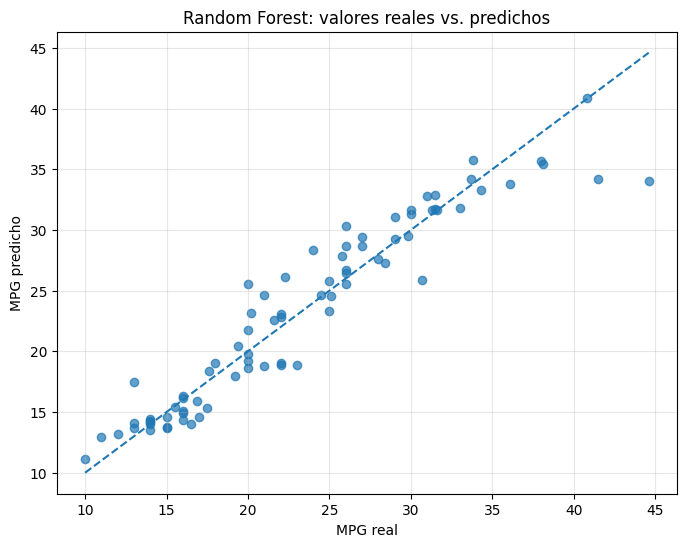

In [48]:
import matplotlib.pyplot as plt

# Predicciones sobre el conjunto de prueba
y_pred = regressor.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

# Línea ideal: predicción = valor real
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("MPG real")
plt.ylabel("MPG predicho")
plt.title("Random Forest: valores reales vs. predichos")

plt.grid(alpha=0.3)
plt.show()

2. Importancia de las variables

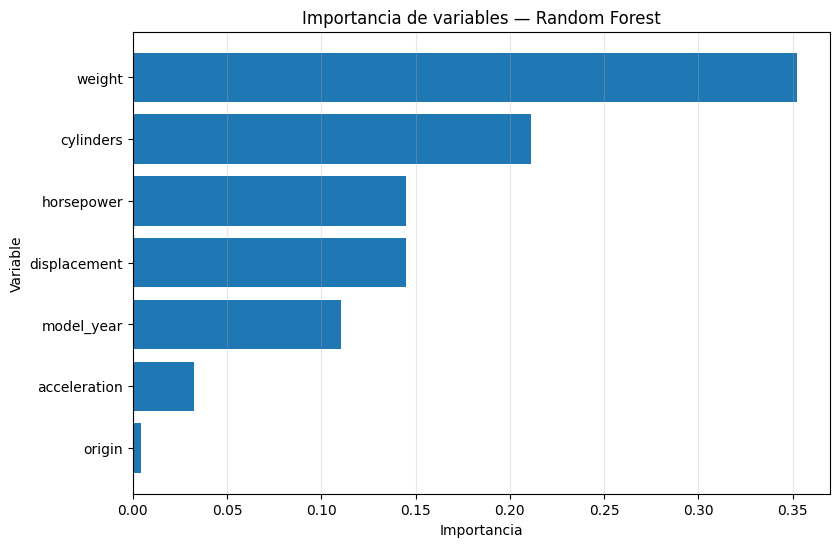

,Variable,Importancia
3,weight,0.35
1,cylinders,0.21
2,horsepower,0.14
0,displacement,0.14
5,model_year,0.11
4,acceleration,0.03
6,origin,0.00


In [49]:
import pandas as pd
import matplotlib.pyplot as plt

variables = [
    "displacement",
    "cylinders",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin"
]

importancias = pd.DataFrame({
    "Variable": variables,
    "Importancia": regressor.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    importancias["Variable"],
    importancias["Importancia"]
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de variables — Random Forest")

plt.grid(axis="x", alpha=0.3)
plt.show()

display(
    importancias.sort_values(
        by="Importancia",
        ascending=False
    )
)

3. Visualizar uno de los árboles del Random Forest

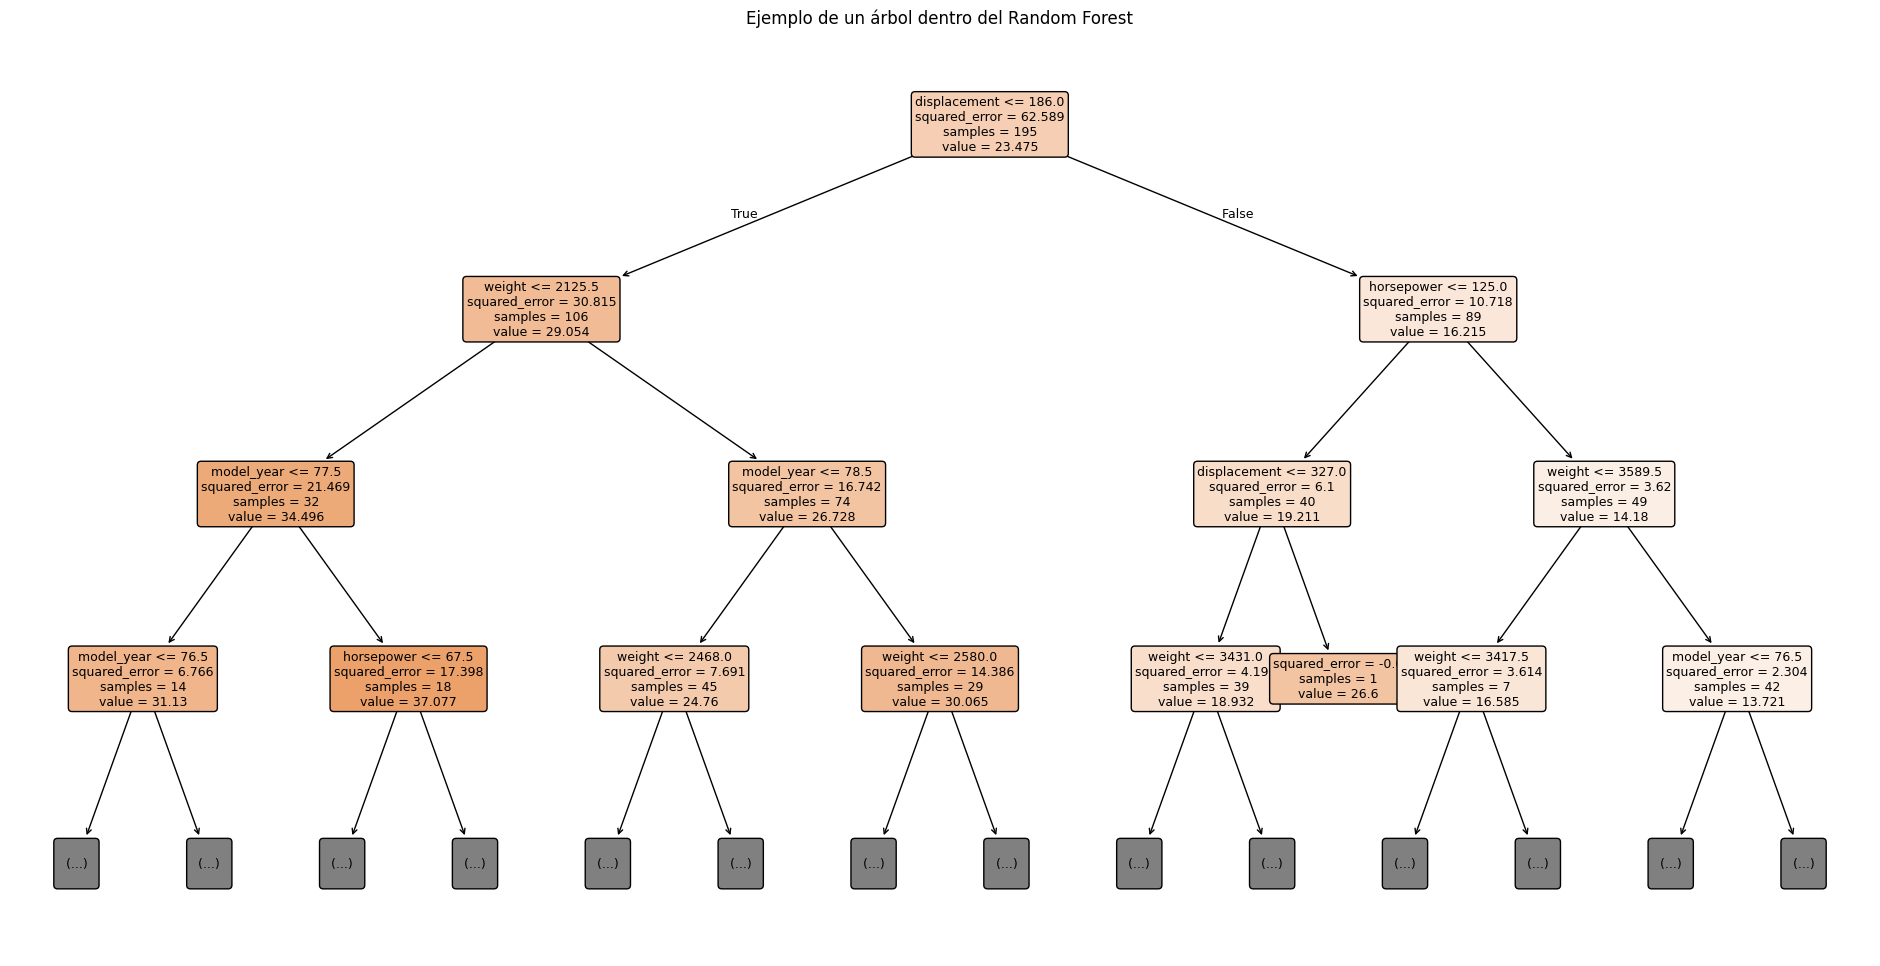

In [50]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Seleccionamos el primer árbol del Random Forest
arbol = regressor.estimators_[0]

plt.figure(figsize=(24, 12))

plot_tree(
    arbol,
    feature_names=variables,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("Ejemplo de un árbol dentro del Random Forest")
plt.show()

4. Una gráfica adicional muy buena: errores del modelo

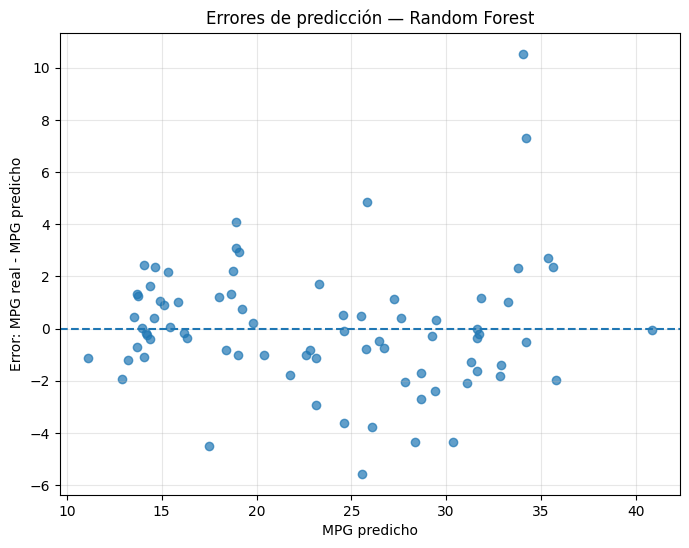

In [51]:
errores = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    errores,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("MPG predicho")
plt.ylabel("Error: MPG real - MPG predicho")
plt.title("Errores de predicción — Random Forest")

plt.grid(alpha=0.3)
plt.show()

## ÁRBOL DE DECISIÓN

In [52]:
from sklearn.tree import DecisionTreeRegressor

dt_regressor = DecisionTreeRegressor(
    random_state=0
)

dt_regressor.fit(X_train, y_train);

In [61]:
prediccion_prueba_dt = dt_regressor.predict(X_train[0:1])

print("Datos del vehículo:")
print(X_test[0])

print("\nMPG real:")
print(y_test[0])

print("\nMPG predicho por Árbol de Decisión:")
print(prediccion_prueba_dt[0])

Datos del vehículo:
[9.000e+01 4.000e+00 7.500e+01 2.125e+03 1.450e+01 7.400e+01 1.000e+00]

MPG real:
28.0

MPG predicho por Árbol de Decisión:
33.5


Realizamos la predicción

In [58]:
prediccion_prueba_dt = regressor.predict(X_train[0:1])

print("Datos del vehículo:")
print(X_train[0])

print("\nMPG predicho:")
print(prediccion_prueba_dt)

Datos del vehículo:
[  85.     4.    70.  1945.    16.8   77.     3. ]

MPG predicho:
[32.8745]


In [59]:
y_pred_dt = dt_regressor.predict(X_train)

y_pred_dt

array([33.5, 20.5, 34.2, 24. , 24. , 14. , 23.9, 24. , 32.9, 31.8, 21.5,
       25.5, 15. , 21.5, 19. , 38. , 23. , 35.1, 23. , 31. , 39.4, 12. ,
       25. , 24. , 26.5, 34.7, 28.8, 28. , 18.2, 44. , 14. , 15.5, 36. ,
       25.5, 19.2, 26. , 25. , 27. , 17.5, 31. , 17. , 26. , 32.3, 11. ,
       20.5, 13. , 15. , 26. , 33.5, 39. , 32.2, 21. , 15. , 23. , 28. ,
       15. , 26.4, 12. , 24.2, 15.5, 23. , 29. , 27. , 15. , 29. , 21. ,
       27.4, 14. , 23.2, 15. , 15. , 35.7, 16.2, 18. , 16. , 37. , 17. ,
       18.5, 16. , 14. , 19.9, 25. , 17. , 22. , 30. , 25.4, 21. , 19. ,
       36. , 19.2, 20.2, 13. , 14. , 36. , 20.2, 33. , 27. , 20.6, 32.4,
       30. , 29.8, 37.7, 11. , 18. , 37. , 16. , 18. , 24. , 13. , 14. ,
       17. , 22. , 21.1, 20.3, 17.5, 19. , 18.1, 20.2, 21. , 17.7, 18. ,
       19. , 32. , 13. , 19. , 23. , 23.9, 36.4, 14. , 27. , 21.5, 22. ,
       26. , 30.5, 15. , 14. , 23.7, 13. , 38. , 32.7, 15. , 13. , 18. ,
       27. , 22. , 32. , 20. , 30.5, 14.5, 19. , 27

In [56]:
y_pred  # Predicciones Random Forest


array([27.5985, 26.083 , 13.2   , 35.646 , 35.7715, 20.399 , 35.3925,
       31.297 , 18.6595, 25.5625, 28.692 , 14.05  , 24.608 , 12.93  ,
       15.8685, 34.213 , 22.6125, 14.385 , 26.4845, 27.2665, 17.492 ,
       16.171 , 21.7805, 25.7785, 34.186 , 13.5425, 27.8295, 24.56  ,
       19.2335, 14.6225, 19.801 , 31.6135, 23.113 , 30.343 , 18.7745,
       29.4825, 32.832 , 14.07  , 14.9225, 13.975 , 13.7675, 34.0605,
       31.647 , 14.365 , 31.076 , 15.097 , 29.272 , 13.7225, 15.3255,
       19.005 , 25.507 , 14.5905, 11.1125, 22.81  , 33.279 , 25.8355,
       23.1405, 18.897 , 31.813 , 24.628 , 19.0615, 28.3485, 32.895 ,
       13.68  , 26.7345, 16.34  , 14.23  , 29.403 , 23.2965, 40.834 ,
       33.7875, 31.6055, 18.408 , 15.4275, 18.9025, 14.1525, 28.6995,
       18.0015, 31.7075])

In [ ]:
y_pred_dt   # Predicciones Árbol de Decisión

## Random Forest

In [65]:
prediccion_prueba_rf = regressor.predict(X_test[0:1])

print("Datos del vehículo:")
print(X_test[0])

print("\nMPG real:")
print(y_test[0])

print("\nMPG predicho por Random Forest:")
print(prediccion_prueba_rf[0])

Datos del vehículo:
[9.000e+01 4.000e+00 7.500e+01 2.125e+03 1.450e+01 7.400e+01 1.000e+00]

MPG real:
28.0

MPG predicho por Random Forest:
27.598500000000005


## Árbol de decisión

In [66]:
prediccion_prueba_dt = dt_regressor.predict(X_test[0:1])

print("Datos del vehículo:")
print(X_test[0])

print("\nMPG real:")
print(y_test[0])

print("\nMPG predicho por Árbol de Decisión:")
print(prediccion_prueba_dt[0])

Datos del vehículo:
[9.000e+01 4.000e+00 7.500e+01 2.125e+03 1.450e+01 7.400e+01 1.000e+00]

MPG real:
28.0

MPG predicho por Árbol de Decisión:
27.0


## Comparación

In [67]:
prediccion_dt = dt_regressor.predict(X_test[0:1])[0]
prediccion_rf = regressor.predict(X_test[0:1])[0]

print("Datos del vehículo:")
print(X_test[0])

print("\nMPG real:")
print(y_test[0])

print("\nMPG predicho - Árbol de Decisión:")
print(prediccion_dt)

print("\nMPG predicho - Random Forest:")
print(prediccion_rf)

Datos del vehículo:
[9.000e+01 4.000e+00 7.500e+01 2.125e+03 1.450e+01 7.400e+01 1.000e+00]

MPG real:
28.0

MPG predicho - Árbol de Decisión:
27.0

MPG predicho - Random Forest:
27.598500000000005


## Métricas

In [69]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_percentage_error
)

# ============================================================
# RANDOM FOREST
# ============================================================

y_pred_rf = regressor.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

mape_rf = mean_absolute_percentage_error(
    y_test,
    y_pred_rf
) * 100


# ============================================================
# ÁRBOL DE DECISIÓN
# ============================================================

y_pred_dt = dt_regressor.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)

rmse_dt = np.sqrt(
    mean_squared_error(y_test, y_pred_dt)
)

mape_dt = mean_absolute_percentage_error(
    y_test,
    y_pred_dt
) * 100


# ============================================================
# RESULTADOS
# ============================================================

print("RANDOM FOREST")
print(f"R²: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.2f} MPG")
print(f"MAPE: {mape_rf:.2f}%")

print("\nÁRBOL DE DECISIÓN")
print(f"R²: {r2_dt:.4f}")
print(f"RMSE: {rmse_dt:.2f} MPG")
print(f"MAPE: {mape_dt:.2f}%")

RANDOM FOREST
R²: 0.9052
RMSE: 2.43 MPG
MAPE: 7.49%

ÁRBOL DE DECISIÓN
R²: 0.7432
RMSE: 4.00 MPG
MAPE: 11.33%


In [70]:
comparacion_metricas = pd.DataFrame({
    "Modelo": [
        "Random Forest",
        "Árbol de Decisión"
    ],
    "R²": [
        r2_rf,
        r2_dt
    ],
    "RMSE (MPG)": [
        rmse_rf,
        rmse_dt
    ],
    "MAPE (%)": [
        mape_rf,
        mape_dt
    ]
})

comparacion_metricas

,Modelo,R²,RMSE (MPG),MAPE (%)
0,Random Forest,0.91,2.43,7.49
1,Árbol de Decisión,0.74,4.00,11.33
